# ISD - TP 3: Outils pour le calcul scientifique II
*(Rendu par:  **Ivan Vecerina** et **Nascimento Santos Stéphane**)*

>Objectifs :
>- Se familiariser avec la bibliothèque Pandas de gestion et traitement des dataframes.
>- Mise en pratique de l'analyse et la caractérisation simple des attributes d'une base de données.


<br>

## Partie 1: Analyse de données socio-économiques (gapminder)

>La fondation gapminder fondé par Hans Rosling et famille fournit une base de
données sur les pays, des outils d’analyse et des études d’analyse socioéconomique
très intéressantes. Nous allons utiliser une petite base de données
contenant la population, l’espérance de vie et le PIB par habitant pour différents
pays du monde de 1952 à 2007, pour faire quelques analyses.


<br>

### Prérequis: Librairies, Data imports, Fonctions et Constantes globales utilisées

In [413]:
import numpy        as np
import pandas       as pd

from matplotlib     import pyplot    as plt
from gapminder      import gapminder as gpm

#Trouvé sur stackoverflow
def autolabel(rects):
    """Attaches a text label above each bar in rects, displaying its height."""
    for rect in rects:
        height = round(rect.get_height(), 1)
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

<br>

**1) Utilisation des méthodes head(), describe() et info() pour nous familiariser avec le dataframe de gapminder.**

In [414]:
gpm.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [415]:
gpm.describe()

,year,lifeExp,pop,gdpPercap
count,1704.00000,1704.000000,1.704000e+03,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081
std,17.26533,12.917107,1.061579e+08,9857.454543
min,1952.00000,23.599000,6.001100e+04,241.165876
25%,1965.75000,48.198000,2.793664e+06,1202.060309
50%,1979.50000,60.712500,7.023596e+06,3531.846988
75%,1993.25000,70.845500,1.958522e+07,9325.462346
max,2007.00000,82.603000,1.318683e+09,113523.132900


In [416]:
gpm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


<br>

**2) Utilisation la commande pandas.DataFrame.hist(gapminder) afin de se faire
une idée plus précise des valeurs dans la base de données.**

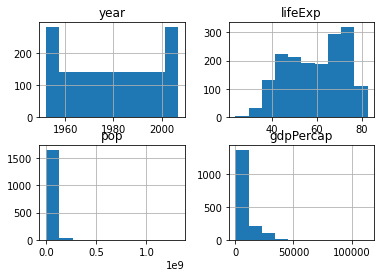

In [417]:
pd.DataFrame.hist(gpm)
plt.show()

**Q1. Que pouvez-vous conclure à partir de ces histogrammes ?**

*On a l'impression d'avoir le double de données pour les années 1952 et 2007*

<br>

**3) Trouvons combien d’observations il y a par pays (c.a.d., combien de données par année par pays)
et vérifions s’il y a des données manquantes.**

In [418]:
print("Valeurs manquantes ou nulles:          ", gpm.isnull().any(axis=1).sum())
print("Nombres distincts d'entrées par Pays:  ", gpm['country'].value_counts().unique())
print("Nombres distincts d'entrées par Année: ", gpm['year'].value_counts().unique())
print("Pas de valeurs manquantes et 12 * 142 = 1704 ce qui correspond au nombre de lignes du tableau. "
      "On a donc bien des données pour chaque pays pour chaque année contrairement à l'impression "
      "que nous avions précédemment.")

Valeurs manquantes ou nulles:           0
Nombres distincts d'entrées par Pays:   [12]
Nombres distincts d'entrées par Année:  [142]
Pas de valeurs manquantes et 12 * 142 = 1704 ce qui correspond au nombre de lignes du tableau. On a donc bien des données pour chaque pays pour chaque année contrairement à l'impression que nous avions précédemment.


<br>

**4) Listons les valeurs uniques présentes dans les colonnes ‘continent’, ‘country’, et ‘year’.**

In [419]:
print("Liste Continents: ", gpm['continent'].unique())
print("--------------------------------------------------------------------------------------------------------------")
print("Liste Pays: ")
print(gpm['country'].unique())
print("--------------------------------------------------------------------------------------------------------------")
print("Liste Années: ", gpm['year'].unique())

Liste Continents:  ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
--------------------------------------------------------------------------------------------------------------
Liste Pays: 
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Argentina' 'Australia'
 'Austria' 'Bahrain' 'Bangladesh' 'Belgium' 'Benin' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso'
 'Burundi' 'Cambodia' 'Cameroon' 'Canada' 'Central African Republic'
 'Chad' 'Chile' 'China' 'Colombia' 'Comoros' 'Congo, Dem. Rep.'
 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba'
 'Czech Republic' 'Denmark' 'Djibouti' 'Dominican Republic' 'Ecuador'
 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Ethiopia' 'Finland'
 'France' 'Gabon' 'Gambia' 'Germany' 'Ghana' 'Greece' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Haiti' 'Honduras' 'Hong Kong, China' 'Hungary' 'Iceland'
 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica'
 'Japan' 'Jordan' 'Kenya' 'Korea, Dem. Rep.' 'K

<br>

**5) Calculons la moyenne de l’espérance de vie de tous les pays en 1952 et en 2007.<br>
Générons un bar chart permettant la comparaison de ces moyennes.**

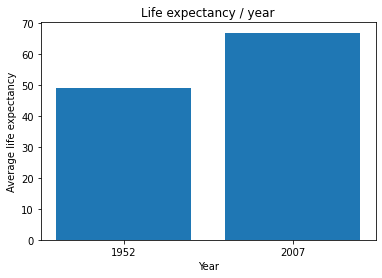

In [420]:
a1 = np.mean(gpm.loc[gpm["year"] == 1952, 'lifeExp'])
a2 = np.mean(gpm.loc[gpm["year"] == 2007, 'lifeExp'])

year = [1952, 2007]
avgLifeExp = [a1, a2]
x = np.arange(len(year))

plt.bar(x, avgLifeExp)
plt.xticks(x, year)

plt.title('Life expectancy / year')
plt.xlabel('Year')
plt.ylabel('Average life expectancy')

plt.show()

<br>

**6) Calculons la moyenne de l’espérance de vie des pays par continent en 1952 et en 2007.<br>
Générons un bar chart permettant la comparaison de ces moyennes.**

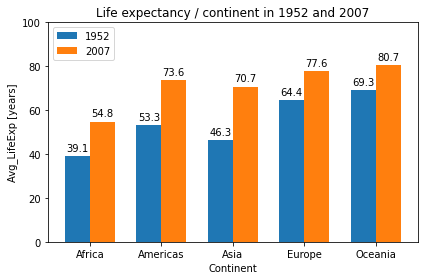

In [421]:
means_1952 = gpm.loc[gpm["year"] == 1952, ['continent', 'lifeExp']].groupby('continent').mean()['lifeExp']
means_2007 = gpm.loc[gpm["year"] == 2007, ['continent', 'lifeExp']].groupby('continent').mean()['lifeExp']
continent  = gpm['continent'].sort_values().unique()

x = np.arange(len(continent))
width = 0.35

fig, ax = plt.subplots()
bar_1952 = ax.bar(x - width/2, means_1952, width, label='1952')
bar_2007 = ax.bar(x + width/2, means_2007, width,label='2007')

ax.set_title('Life expectancy / continent in 1952 and 2007')
ax.set_ylabel('Avg_LifeExp [years]')
ax.set_xlabel('Continent')
ax.set_xticks(x)
ax.set_xticklabels(continent)
ax.legend(loc='upper left')
ax.set_ylim(0, 100)

autolabel(bar_1952)
autolabel(bar_2007)

fig.tight_layout()


plt.show()

**Q2. Quel continent a eu la plus grande progression ?**

*C'est l'Asie, avec une augmentation phénoménale de presque 25 ans.*

<br>

**7) Générons un plot montrant l’évolution de 1952 à 2007 de la moyenne de la
population par continent.**

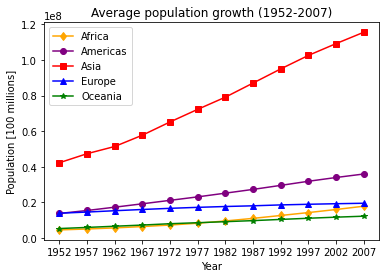

In [422]:
pop_Africa   = gpm.loc[gpm["continent"] == 'Africa',   ['year', 'pop']].groupby('year').mean()['pop']
pop_Americas = gpm.loc[gpm["continent"] == 'Americas', ['year', 'pop']].groupby('year').mean()['pop']
pop_Asia     = gpm.loc[gpm["continent"] == 'Asia',     ['year', 'pop']].groupby('year').mean()['pop']
pop_Europe   = gpm.loc[gpm["continent"] == 'Europe',   ['year', 'pop']].groupby('year').mean()['pop']
pop_Oceania  = gpm.loc[gpm["continent"] == 'Oceania',  ['year', 'pop']].groupby('year').mean()['pop']

years = gpm['year'].sort_values().unique()

x = np.arange(len(years))

plt.plot(x, pop_Africa,     'orange', marker='d', label='Africa')
plt.plot(x, pop_Americas,   'purple', marker='o', label='Americas')
plt.plot(x, pop_Asia,       'red',    marker='s', label='Asia')
plt.plot(x, pop_Europe,     'blue',   marker='^', label='Europe')
plt.plot(x, pop_Oceania,    'green',  marker='*', label='Oceania')

plt.title('Average population growth (1952-2007)')
plt.xlabel('Year')
plt.ylabel('Population [100 millions]')
plt.xticks(x)
plt.xticks(x, years)
plt.legend(loc='upper left')

plt.show()

**Q3. Que pouvez-vous conclure à partir de ces plots ?**

*L'accroissement de la population par continent est plus au moins linéaire.
Et que pour les continents les plus développés on remarque accroissement plus lent*

<br>

**8) Générons deux sub-plots contenant un scatter plot avec l’espérance de vie des
pays sur l’axe y et le PIB per capita sur l’axe x, pour l’année 1952 et séparément
pour l’année 2007. Indiquons le continent par une couleur.**

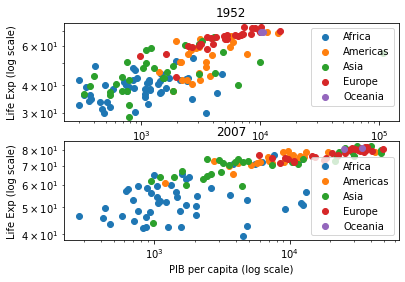

In [423]:
fig, ax = plt.subplots(2)

groups = gpm.groupby('continent')

for name, group in groups:
    data_1952 = gpm.loc[(gpm["year"] == 1952) & (gpm["continent"] == name)]

    ax[0].scatter(data_1952['gdpPercap'], data_1952['lifeExp'], label=name)

ax[0].set_xlabel('PIB per capita (log scale)')
ax[0].set_ylabel('Life Exp (log scale)')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].legend()
ax[0].set_title('1952')

for name, group in groups:
    data_2007 = gpm.loc[(gpm["year"] == 2007) & (gpm["continent"] == name)]

    ax[1].scatter(data_2007['gdpPercap'], data_2007['lifeExp'], label=name)

ax[1].set_xlabel('PIB per capita (log scale)')
ax[1].set_ylabel('Life Exp (log scale)')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].legend()
ax[1].set_title('2007')

plt.show()

**Q4. Que pouvez-vous conclure à partir de ces scatter plots ?**

*On peut remarquer un rapport logarithmique entre le PIB per Capita et l'espérance de vie.<br>
Donc on voit que plus le PIB per capita a augmenté, plus l'espérance de vie augmente.*

<br>

**9) La fonction scatter de matplotlib permet non seulement d’indiquer une couleur
mais aussi la taille de chaque « point ». Générez des scatter plots de l’espérance
de vie vs. PIB par habitant (années 1952 et 2007) et visualisez la population
associée à chaque pays à l’aide d’un cercle de taille proportionnel à la
population. Indiquez le continent par une couleur.**

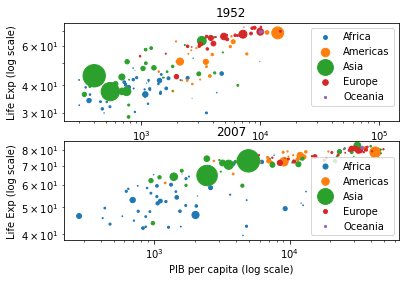

In [424]:
fig, ax = plt.subplots(2)

max_pop_1952 = gpm.loc[(gpm["year"] == 1952)]['pop'].max() / 500
max_pop_2007 = gpm.loc[(gpm["year"] == 2007)]['pop'].max() / 500

groups = gpm.groupby('continent')

for name, group in groups:
    data_1952 = gpm.loc[(gpm["year"] == 1952) & (gpm["continent"] == name)]

    ax[0].scatter(data_1952['gdpPercap'], data_1952['lifeExp'], s=data_1952['pop']/max_pop_1952, label=name)

ax[0].set_xlabel('PIB per capita (log scale)')
ax[0].set_ylabel('Life Exp (log scale)')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].legend()
ax[0].set_title('1952')

for name, group in groups:
    data_2007 = gpm.loc[(gpm["year"] == 2007) & (gpm["continent"] == name)]

    ax[1].scatter(data_2007['gdpPercap'], data_2007['lifeExp'], s=data_2007['pop']/max_pop_2007, label=name)

ax[1].set_xlabel('PIB per capita (log scale)')
ax[1].set_ylabel('Life Exp (log scale)')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].legend()
ax[1].set_title('2007')

plt.show()

<br>

**10) Générez un scatter plot montrant l’augmentation de la population entre 1952 et
2007 (axe y) par rapport au PIB per capita. Indiquez le continent par une couleur.**

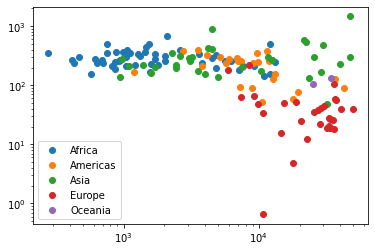

In [425]:
new_df = gpm.sort_values(by='country')

pop_1952 = new_df.loc[new_df["year"] == 1952]['pop'].to_numpy()
pop_2007 = new_df.loc[new_df["year"] == 2007]['pop'].to_numpy()

#pop_increase = (pop_2007 / pop_1952 - 1) * 100
#gdpPercap    = new_df.loc[new_df["year"] == 2007]['gdpPercap'].to_numpy()

df = new_df.loc[new_df["year"] == 2007, ['continent', 'country']]
df['pop_increase'] = (pop_2007 / pop_1952 - 1) * 100
df['gdpPercap']    = new_df.loc[new_df["year"] == 2007]['gdpPercap'].to_numpy()

groups = df.groupby('continent')

for name, group in groups:
    df_sub = df.loc[gpm["continent"] == name]

    plt.scatter(df_sub['gdpPercap'], df_sub['pop_increase'], label=name)

plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.show()

**Q5. Que pouvez-vous observer dans cette figure et que pouvez-vous conclure ?**

*On constate une tendance vers plus le PIB per capita est bas, plus la population a accrue.
L'inverse n'étant pas nécessairement vrai.*